In [1]:
import pandas as pd
financial_df = pd.read_csv('/Users/alecxszhang/Desktop/Stat 359/data/Financial_tweets.csv')
politics_df = pd.read_csv("/Users/alecxszhang/Desktop/Stat 359/data/politics_sentiment.csv")
videogames_df = pd.read_csv("/Users/alecxszhang/Desktop/Stat 359/data/videogames_train.csv")
nfl_df = pd.read_csv("/Users/alecxszhang/Desktop/Stat 359/data/nfl_sentiments.csv")
none_df = pd.read_csv("/Users/alecxszhang/Desktop/Stat 359/data/none_sentiment.csv")


In [2]:
# Classify sentiment based on score thresholds
def classify_sentiment(score):
    if score < -0.1:
        return 'negative'
    elif score > 0.1:
        return 'positive'
    else:
        return 'neutral'

# Apply sentiment classification to each row and tag the domain
financial_df['sentiment'] = financial_df['score'].apply(classify_sentiment)
financial_df['domain'] = 'financial'

# Standardize text column name for consistency across datasets
financial_df = financial_df.rename(columns={'full_text': 'text'})

from sklearn.model_selection import train_test_split

# Split into train/test sets (80/20), stratified to preserve sentiment distribution
train_fin_df, test_fin_df = train_test_split(
    financial_df[['text', 'sentiment', 'domain']],
    test_size=0.2,
    random_state=42,
    stratify=financial_df['sentiment']
)

In [3]:
# Normalize sentiment labels to lowercase for consistency
videogames_df['sentiment'] = videogames_df['sentiment'].str.lower()

# Tag the domain
videogames_df['domain'] = 'videogames'

# Split into train/test sets (80/20), stratified to preserve sentiment distribution
train_vg_df, test_vg_df = train_test_split(
    videogames_df[['text', 'sentiment', 'domain']],
    test_size=0.2,
    random_state=42,
    stratify=videogames_df['sentiment']
)

In [4]:
# drop NA
print(politics_df['sentiment'].value_counts(dropna=False)) 

print(politics_df['sentiment'].dtype)

sentiment
0.0    2475
1.0    2420
2.0     556
NaN       3
Name: count, dtype: int64
float64


In [5]:
# Tag the domain
politics_df['domain'] = 'politics'

# Standardize text column name for consistency across datasets
politics_df = politics_df.rename(columns={'tweet': 'text'})

# Map numeric sentiment labels to string equivalents
politics_df['sentiment'] = politics_df['sentiment'].map({0: 'negative', 1: 'positive', 2: 'neutral'})

# Drop rows where sentiment mapping failed (unmapped/unexpected values)
politics_df = politics_df.dropna(subset=['sentiment'])

# Split into train/test sets (80/20), stratified to preserve sentiment distribution
train_pol_df, test_pol_df = train_test_split(
    politics_df[['text', 'sentiment', 'domain']],
    test_size=0.2,
    random_state=42,
    stratify=politics_df['sentiment']
)

In [6]:
# Tag as domain-agnostic samples
none_df["domain"] = "none"

# Standardize text column name for consistency across datasets
none_df = none_df.rename(columns={'tweet': 'text'})

# Map numeric sentiment labels to string equivalents
none_df['sentiment'] = none_df['sentiment'].map({0: 'negative', 1: 'positive', 2: 'neutral'})

# Drop rows where sentiment mapping failed (unmapped/unexpected values)
none_df = none_df.dropna(subset=['sentiment'])

# Split into train/test sets (80/20), stratified to preserve sentiment distribution
train_none_df, test_none_df = train_test_split(
    none_df[['text', 'sentiment', 'domain']],
    test_size=0.2,
    random_state=42,
    stratify=none_df['sentiment']
)

In [7]:
# Tag the domain
nfl_df['domain'] = 'nfl'

# Filter to only tweets that mention NFL-related keywords to remove off-topic scraped content
import re
nfl_keywords = r'\b(nfl|football|touchdown|quarterback|qb|mahomes|brady|receiver|linebacker|' \
               r'packers|chiefs|eagles|cowboys|49ers|ravens|browns|patriots|bills|' \
               r'draft|super bowl|playoffs|offense|defense|interception|fumble|yard|'\
               r'rushing|passing|receiver|tight end|kicker)\b'

nfl_df = nfl_df[nfl_df['text'].str.contains(nfl_keywords, case=False, regex=True)]

# Keep only rows with valid sentiment labels (drop any unexpected values)
nfl_df = nfl_df[nfl_df['sentiment'].isin(['negative', 'positive', 'neutral'])]

# Split into train/test sets (80/20), stratified to preserve sentiment distribution
train_nfl_df, test_nfl_df = train_test_split(
    nfl_df[['text', 'sentiment', 'domain']],
    test_size=0.2,
    random_state=42,
    stratify=nfl_df['sentiment']
)

/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_999/2387575275.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  nfl_df = nfl_df[nfl_df['text'].str.contains(nfl_keywords, case=False, regex=True)]


In [8]:
#combine into one dataset
combined_df = pd.concat([
    train_vg_df[['text', 'sentiment', 'domain']],
    train_pol_df[['text', 'sentiment', 'domain']],
    train_fin_df[['text', 'sentiment', 'domain']],
    train_nfl_df[['text', 'sentiment', 'domain']],
    train_none_df[['text', 'sentiment', 'domain']]
    
], ignore_index=True)


combined_df.head()

,text,sentiment,domain
0,I MISS HIM ALREADY,positive,videogames
1,Although I might actually actually try out fab...,positive,videogames
2,Why,neutral,videogames
3,I decided to hop back into the Battlefield Har...,positive,videogames
4,Shit pic.twitter.com / ra0gwVDlt3,negative,videogames


In [23]:
# Find the smallest domain to use as the cap for balancing
min_count = combined_df['domain'].value_counts().min()
print(f"Balancing to {min_count} rows per domain")

# Downsample each domain to the same size for a balanced dataset
combined_df = combined_df.groupby('domain').apply(
    lambda x: x.sample(min_count, random_state=42)
).reset_index(drop=True)

print(combined_df['domain'].value_counts())

# Sample the same number of rows from the domain-agnostic set
none_samples = none_df.sample(min_count, random_state=42)[['text', 'sentiment']].copy()
none_samples['domain'] = 'none'

# NOTE: sentiment140 remapping no longer applies — sentiment labels are already strings
none_samples['sentiment'] = none_samples['sentiment'].map({0: 'negative', 4: 'positive'})

# Append the none samples to the balanced combined dataset
combined_df = pd.concat([
    combined_df,
    none_samples
], ignore_index=True)

combined_df['domain'].value_counts()
combined_df['sentiment'].value_counts()

Balancing to 2252 rows per domain
domain
financial     2252
nfl           2252
none          2252
politics      2252
videogames    2252
Name: count, dtype: int64


/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_999/131511845.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df = combined_df.groupby('domain').apply(


sentiment
negative    4444
positive    4181
neutral     2635
Name: count, dtype: int64

In [10]:
# save dataframe
combined_df.to_csv('/Users/alecxszhang/Desktop/Stat 359/data/combined_df.csv', index=False)

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import evaluate

# Device 
# Prefer MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# Label mappings 
# Encode domain and sentiment string labels to integer IDs for the model
domain2id    = {'nfl': 0, 'financial': 1, 'politics': 2, 'videogames': 3, 'none': 4}
id2domain    = {v: k for k, v in domain2id.items()}
sentiment2id = {'negative': 0, 'positive': 1, "neutral" : 2}
id2sentiment = {v: k for k, v in sentiment2id.items()}

# Prep dataframe 

# Map string labels to integer IDs and drop rows with missing values
combined_df['domain_label']    = combined_df['domain'].map(domain2id)
combined_df['sentiment_label'] = combined_df['sentiment'].map(sentiment2id)
combined_df = combined_df.dropna(subset=['text', 'domain_label', 'sentiment_label'])

# Ensure correct types before passing to the model
combined_df['text']            = combined_df['text'].astype(str)
combined_df['domain_label']    = combined_df['domain_label'].astype(int)
combined_df['sentiment_label'] = combined_df['sentiment_label'].astype(int)

# Stratify by domain to preserve class distribution across splits
train_df, val_df = train_test_split(
    combined_df[['text', 'domain_label', 'sentiment_label']],
    test_size=0.2,
    random_state=42,
    stratify=combined_df['domain_label']
)

# Tokenizer & datasets
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenize text and attach both task labels to each example
def tokenize(examples):
    tokens = tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)
    tokens['labels']           = examples['domain_label']
    tokens['sentiment_labels'] = examples['sentiment_label']
    return tokens

train_ds = Dataset.from_pandas(train_df).map(tokenize, batched=True)
val_ds   = Dataset.from_pandas(val_df).map(tokenize, batched=True)

# Multi-task model 
# Shared DistilBERT backbone with two separate classification heads:
# one for domain prediction, one for sentiment prediction
class MultiTaskModel(nn.Module):
    def __init__(self, backbone, num_domains, num_sentiments, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        hidden = backbone.config.hidden_size

        self.domain_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, num_domains)
        )
        self.sentiment_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, num_sentiments)
        )

    def forward(self, input_ids, attention_mask, labels=None, sentiment_labels=None):
        outputs   = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        # Use the [CLS] token representation as the sequence embedding
        cls_token = outputs.last_hidden_state[:, 0, :]

        domain_logits    = self.domain_head(cls_token)
        sentiment_logits = self.sentiment_head(cls_token)

        # Combine both task losses equally when labels are provided
        loss = None
        if labels is not None and sentiment_labels is not None:
            domain_loss    = F.cross_entropy(domain_logits, labels)
            sentiment_loss = F.cross_entropy(sentiment_logits, sentiment_labels)
            loss           = domain_loss + sentiment_loss

        return {
            'loss':             loss,
            'domain_logits':    domain_logits,
            'sentiment_logits': sentiment_logits,
        }

backbone = AutoModel.from_pretrained('distilbert-base-uncased')
model    = MultiTaskModel(backbone, num_domains=5, num_sentiments=3).to(device)

# Custom Trainer 
# Override Trainer to handle the multi-output dict returned by the model
class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        loss    = outputs['loss']
        return (loss, outputs) if return_outputs else loss

    # Return logits and labels for both tasks so compute_metrics receives them
    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)
        with torch.no_grad():
            outputs = model(**inputs)

        loss   = outputs['loss']
        logits = (outputs['domain_logits'], outputs['sentiment_logits'])
        labels = (inputs.get('labels'), inputs.get('sentiment_labels'))
        return loss, logits, labels

# Compute accuracy independently for each task
def compute_metrics(eval_pred):
    (domain_logits, sentiment_logits), (domain_labels, sentiment_labels) = eval_pred

    domain_preds    = np.argmax(domain_logits,    axis=-1)
    sentiment_preds = np.argmax(sentiment_logits, axis=-1)

    domain_acc    = (domain_preds    == domain_labels).mean()
    sentiment_acc = (sentiment_preds == sentiment_labels).mean()

    return {
        'domain_accuracy':    round(domain_acc, 4),
        'sentiment_accuracy': round(sentiment_acc, 4),
    }

# Training 
# fp16 enabled only when CUDA is available (not supported on MPS)
training_args = TrainingArguments(
    output_dir='./multitask-classifier',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='domain_accuracy',
    report_to='none',
    logging_steps=10,
    fp16=torch.cuda.is_available(),
)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

# Save 
# Save model weights and tokenizer separately for easy reloading
torch.save(model.state_dict(), './multitask-classifier/model_weights.pt')
tokenizer.save_pretrained('./multitask-classifier')
print("Saved to ./multitask-classifier")

Using device: mps


Map:   0%|          | 0/9008 [00:00<?, ? examples/s]

Map:   0%|          | 0/2252 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Domain Accuracy,Sentiment Accuracy
1,0.808300,0.755102,0.964900,0.723400
2,0.560900,0.754833,0.968900,0.735800
3,0.280100,0.859155,0.969400,0.742900


Saved to ./multitask-classifier


In [12]:
import torch.nn.functional as F

# Minimum probability threshold for a domain to be included in predictions
THRESHOLD = 0.15

def predict(texts, threshold=THRESHOLD):
    # Accept a single string or a list of strings
    if isinstance(texts, str):
        texts = [texts]

    # Tokenize and move inputs to the appropriate device
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    results = []
    for i in range(len(texts)):
        # Convert logits to probabilities for both tasks
        domain_probs    = F.softmax(outputs['domain_logits'][i],    dim=-1)
        sentiment_probs = F.softmax(outputs['sentiment_logits'][i], dim=-1)

        # Include all domains exceeding the threshold; fall back to 'unknown' if none qualify
        domains = [id2domain[j] for j, p in enumerate(domain_probs) if p.item() > threshold] or ['unknown']

        results.append({
            'domains':         domains,
            'domain_scores':   {id2domain[j]: round(p.item(), 3) for j, p in enumerate(domain_probs)},
            'sentiment':       id2sentiment[sentiment_probs.argmax().item()],
            'sentiment_score': round(sentiment_probs.max().item(), 3),
        })

    return results

# Sample tweets spanning multiple domains to sanity-check the model
test_tweets = [
    "The NFL player just signed a huge financial deal",  # cross-domain: nfl + financial
    "Mahomes tore his ACL",                              # nfl
    "NASDAQ dropped 3.5 points today",                   # financial
    "I just had a great lunch today",                    # none
    "Congress passes new bill on healthcare reform",     # politics
]

for tweet, pred in zip(test_tweets, predict(test_tweets)):
    print(f"Tweet:     {tweet}")
    print(f"Domains:   {pred['domains']}")
    print(f"Sentiment: {pred['sentiment']} ({pred['sentiment_score']})")
    print(f"Scores:    {pred['domain_scores']}\n")

Tweet:     The NFL player just signed a huge financial deal
Domains:   ['nfl']
Sentiment: neutral (0.717)
Scores:    {'nfl': 0.938, 'financial': 0.007, 'politics': 0.004, 'videogames': 0.047, 'none': 0.003}

Tweet:     Mahomes tore his ACL
Domains:   ['videogames', 'none']
Sentiment: negative (0.998)
Scores:    {'nfl': 0.1, 'financial': 0.009, 'politics': 0.01, 'videogames': 0.216, 'none': 0.665}

Tweet:     NASDAQ dropped 3.5 points today
Domains:   ['financial']
Sentiment: negative (0.939)
Scores:    {'nfl': 0.007, 'financial': 0.885, 'politics': 0.013, 'videogames': 0.021, 'none': 0.073}

Tweet:     I just had a great lunch today
Domains:   ['none']
Sentiment: positive (0.93)
Scores:    {'nfl': 0.0, 'financial': 0.0, 'politics': 0.001, 'videogames': 0.0, 'none': 0.998}

Tweet:     Congress passes new bill on healthcare reform
Domains:   ['politics']
Sentiment: neutral (0.949)
Scores:    {'nfl': 0.005, 'financial': 0.003, 'politics': 0.989, 'videogames': 0.001, 'none': 0.001}



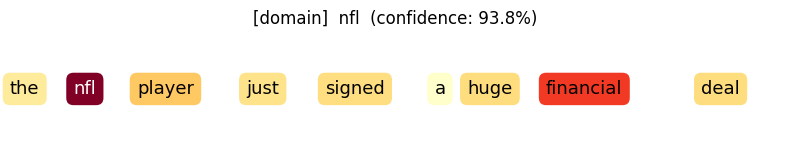

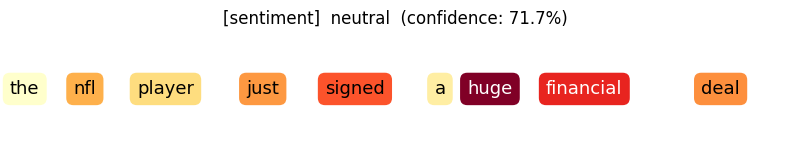

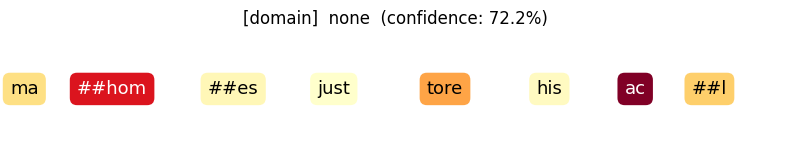

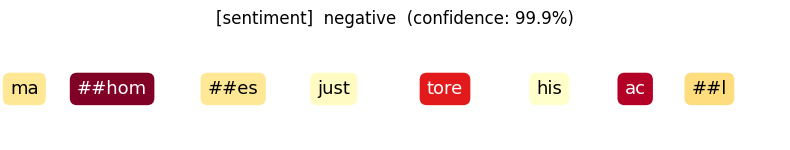

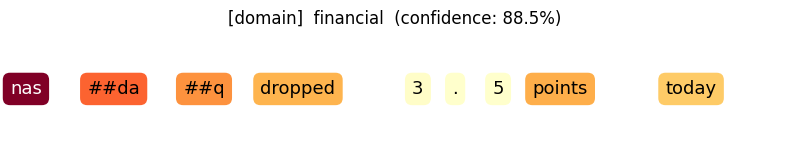

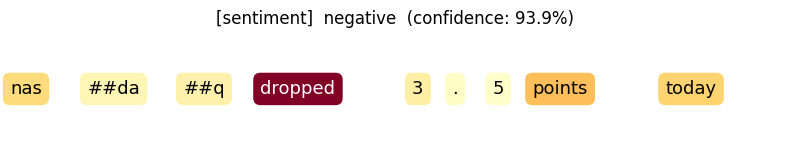

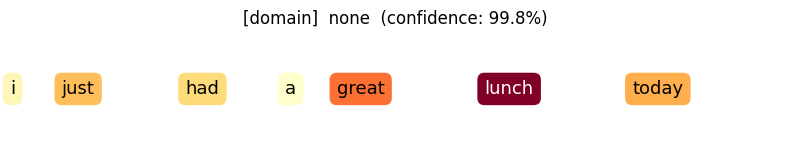

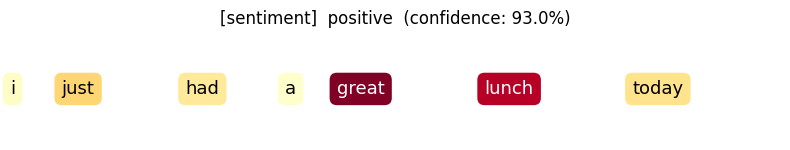

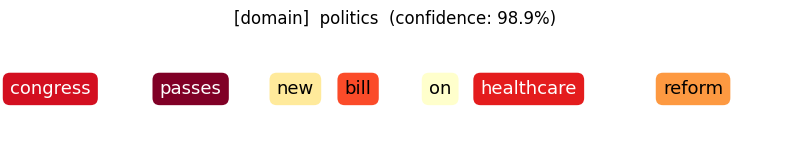

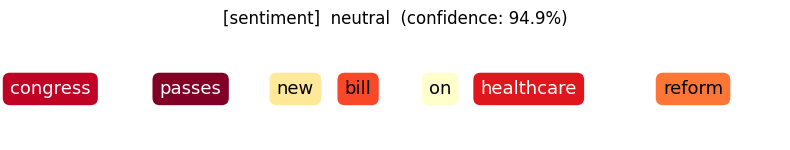

In [13]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def get_saliency(text, model, tokenizer, device, task='domain'):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)

    # Hook into the embedding layer to capture its output and gradients
    embedding_layer = model.backbone.embeddings
    captured = {}

    def forward_hook(module, input, output):
        # Enable gradient tracking on the embedding output
        output.requires_grad_(True)
        output.retain_grad()
        captured['embeddings'] = output

    # Register and immediately remove the hook after the forward pass
    handle = embedding_layer.register_forward_hook(forward_hook)
    outputs = model(**inputs)
    handle.remove()

    # Select logits and decode the predicted label for the requested task
    if task == 'domain':
        logits          = outputs['domain_logits']
        predicted_class = logits.argmax(dim=-1).item()
        label           = id2domain[predicted_class]
    else:
        logits          = outputs['sentiment_logits']
        predicted_class = logits.argmax(dim=-1).item()
        label           = id2sentiment[predicted_class]

    # Backpropagate from the predicted class score to get embedding gradients
    logits[0, predicted_class].backward()

    # Saliency = L2 norm of gradients across the embedding dimension per token
    saliency = captured['embeddings'].grad[0].norm(dim=-1).detach().cpu().numpy()
    tokens   = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())
    score    = torch.softmax(logits, dim=-1)[0, predicted_class].item()

    return tokens, saliency, label, score


def plot_saliency(text, model, tokenizer, device, task='domain'):
    tokens, saliency, label, score = get_saliency(text, model, tokenizer, device, task)

    # Strip [CLS] and [SEP] special tokens before plotting
    tokens   = tokens[1:-1]
    saliency = saliency[1:-1]

    # Normalize saliency scores to [0, 1] for colormap mapping
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.6), 1.6))
    ax.axis('off')

    # Color each token by its saliency — darker = more influential
    cmap = plt.get_cmap("YlOrRd")
    x = 0
    for token, sal in zip(tokens, saliency):
        color = cmap(sal)
        # Switch to white text on high-saliency (dark) backgrounds for readability
        ax.text(x, 0.5, token, ha='left', va='center', fontsize=13,
                bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.4'),
                color='black' if sal < 0.7 else 'white')
        x += len(token) * 0.13 + 0.15

    ax.set_xlim(0, x)
    ax.set_ylim(0, 1)
    ax.set_title(f'[{task}]  {label}  (confidence: {score:.1%})', fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()


# Run saliency visualization for both tasks across all test tweets
test_tweets = [
    "The NFL player just signed a huge financial deal",
    "Mahomes just tore his ACL",
    "NASDAQ dropped 3.5 points today",
    "I just had a great lunch today",
    "Congress passes new bill on healthcare reform"
]

for tweet in test_tweets:
    plot_saliency(tweet, model, tokenizer, device, task='domain')
    plot_saliency(tweet, model, tokenizer, device, task='sentiment')

/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_999/2919561304.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df   = combined_df.groupby('domain').apply(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


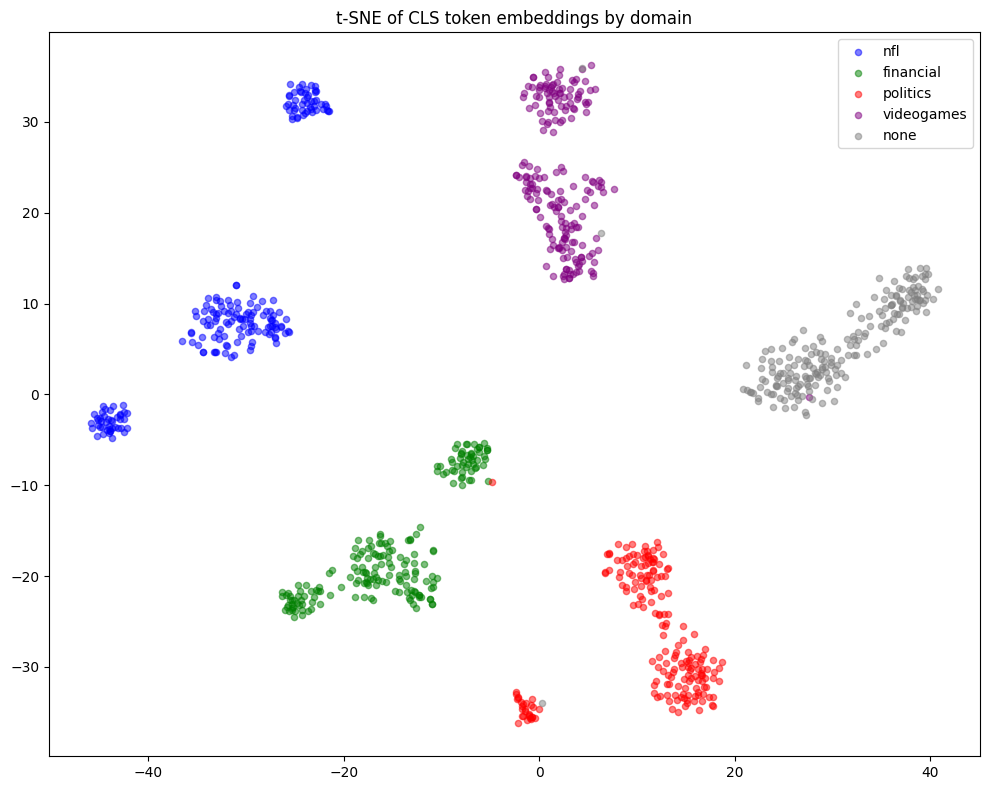

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def get_cls_embeddings(texts, model, tokenizer, device, batch_size=32):
    model.eval()
    all_embeddings = []
    
    # Process in batches to avoid OOM on large inputs
    for i in range(0, len(texts), batch_size):
        batch  = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors='pt', padding=True, 
                          truncation=True, max_length=128).to(device)
        
        with torch.no_grad():
            # Extract backbone embeddings directly (bypassing task heads)
            outputs        = model.backbone(**inputs)
            # Use the [CLS] token as the sentence-level representation
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(cls_embeddings.cpu().numpy())
    
    return np.vstack(all_embeddings)

# Sample up to 200 rows per domain for a balanced t-SNE plot
sample_size = 200
sample_df   = combined_df.groupby('domain').apply(
    lambda x: x.sample(min(sample_size, len(x)), random_state=42)
).reset_index(drop=True)

texts  = sample_df['text'].tolist()
labels = sample_df['domain'].tolist()

embeddings = get_cls_embeddings(texts, model, tokenizer, device)

# Reduce 768-dim CLS embeddings to 2D for visualization
tsne    = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(embeddings)

domain_colors = {
    'nfl':        'blue',
    'financial':  'green',
    'politics':   'red',
    'videogames': 'purple',
    'none':       'gray'
}

plt.figure(figsize=(10, 8))
for domain, color in domain_colors.items():
    mask = [l == domain for l in labels]
    pts  = reduced[mask]
    plt.scatter(pts[:, 0], pts[:, 1], c=color, label=domain, alpha=0.5, s=20)

plt.legend()
plt.title('t-SNE of CLS token embeddings by domain')
plt.tight_layout()
plt.show()

/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_999/3549207312.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df   = combined_df.groupby('domain').apply(


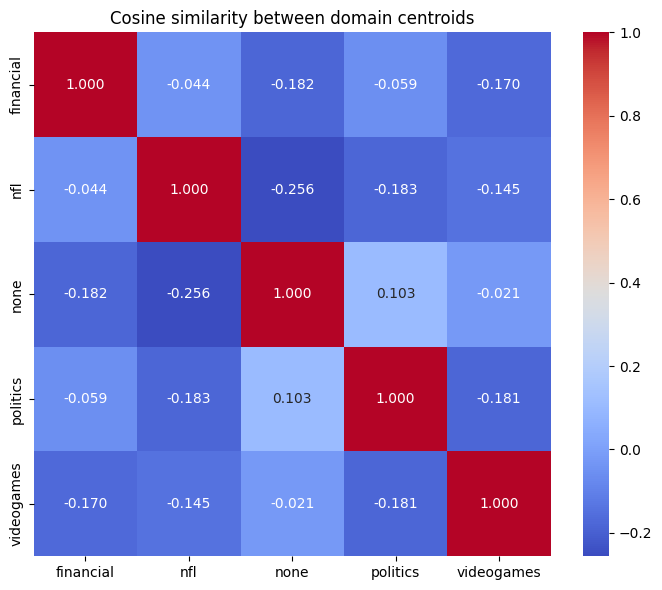

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

# Re-sample in case this cell is run independently of the t-SNE cell
sample_size = 200
sample_df   = combined_df.groupby('domain').apply(
    lambda x: x.sample(min(sample_size, len(x)), random_state=42)
).reset_index(drop=True)

texts  = sample_df['text'].tolist()
labels = sample_df['domain'].tolist()

embeddings = get_cls_embeddings(texts, model, tokenizer, device)

# Compute the mean CLS embedding per domain as its centroid in embedding space
domain_centroids = {}
for domain in combined_df['domain'].unique():
    mask = [l == domain for l in labels]
    domain_centroids[domain] = embeddings[mask].mean(axis=0)

# Build a matrix of centroids and compute pairwise cosine similarities
domains         = list(domain_centroids.keys())
centroid_matrix = np.vstack([domain_centroids[d] for d in domains])
sim_matrix      = cosine_similarity(centroid_matrix)

# Visualize as a heatmap — higher values indicate more similar domain representations
import seaborn as sns
plt.figure(figsize=(7, 6))
sns.heatmap(sim_matrix, xticklabels=domains, yticklabels=domains,
            annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Cosine similarity between domain centroids')
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.lines import Line2D

# Words that carry different meanings depending on domain context
ambiguous_words = {
    'interception': [
        "Mahomes threw an interception in the fourth quarter",
        "The cornerback made an interception at the goal line",
        "The SEC reported an interception of the wire transfer",
        "Police reported an interception at the border",
    ],
    'market': [
        "The stock market crashed after the Fed announcement",
        "The financial market is showing signs of recovery",
        "The quarterback read the defense and found the open market",
        "The new Call of Duty dominated the gaming market",
        "Congress passed a bill to regulate the housing market",
    ],
    'draft': [
        "The NFL draft picks were announced last night",
        "Patrick Mahomes was the 10th overall draft pick",
        "The Fed draft policy proposal was released today",
        "Congress drafted a new healthcare bill",
        "The game developer drafted new patch notes",
        "Fortnite released a draft of their new season roadmap",
    ],
    'trade': [
        "The Lakers completed a blockbuster trade for the star player",
        "Congress approved the new trade deal with China",
        "Apple stock surged after the trade war resolution",
        "The Madden player traded his star quarterback in franchise mode",
    ]
}

# Heuristic domain tagger based on keywords — used only for plot coloring
def guess_domain(sentence):
    s = sentence.lower()
    if any(w in s for w in ['mahomes', 'nfl', 'quarterback', 'cornerback',
                              'draft pick', 'lakers', 'player']):
        return 'nfl/sports', 'blue'
    elif any(w in s for w in ['stock', 'fed', 'financial', 'market crash',
                               'trade war', 'apple stock', 'wire transfer']):
        return 'financial', 'green'
    elif any(w in s for w in ['congress', 'sec', 'bill', 'policy', 'police']):
        return 'politics', 'red'
    elif any(w in s for w in ['fortnite', 'call of duty', 'madden',
                               'gaming', 'game developer']):
        return 'videogames', 'purple'
    else:
        return 'other', 'gray'

def get_word_embedding_in_context(sentences, target_word, model, tokenizer, device):
    model.eval()
    embeddings      = []
    found_sentences = []

    # Tokenize the target word to find its subword root token
    target_tokens = tokenizer.tokenize(target_word)
    root_token    = target_tokens[0]
    print(f"  '{target_word}' tokenizes as: {target_tokens}, matching on root: '{root_token}'")

    for sentence in sentences:
        inputs = tokenizer(sentence, return_tensors='pt',
                          truncation=True, max_length=128).to(device)
        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

        # Locate the target word's token span (root + any ## continuations)
        target_indices = []
        i = 0
        while i < len(tokens):
            if tokens[i] == root_token:
                span = [i]
                j = i + 1
                while j < len(tokens) and tokens[j].startswith('##'):
                    span.append(j)
                    j += 1

In [18]:
import torch.nn.functional as F

# Minimum probability threshold for a domain to be included in predictions
THRESHOLD = 0.15

def predict(texts, threshold=THRESHOLD):
    # Accept a single string or a list of strings
    if isinstance(texts, str):
        texts = [texts]

    # Tokenize and move inputs to the appropriate device
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    results = []
    for i in range(len(texts)):
        # Convert logits to probabilities for both tasks
        domain_probs    = F.softmax(outputs['domain_logits'][i],    dim=-1)
        sentiment_probs = F.softmax(outputs['sentiment_logits'][i], dim=-1)

        # Include all domains exceeding the threshold; fall back to 'unknown' if none qualify
        domains = [id2domain[j] for j, p in enumerate(domain_probs) if p.item() > threshold] or ['unknown']

        results.append({
            'text':            texts[i],
            'domains':         domains,
            'domain_scores':   {id2domain[j]: round(p.item(), 3) for j, p in enumerate(domain_probs)},
            'sentiment':       id2sentiment[sentiment_probs.argmax().item()],
            'sentiment_score': round(sentiment_probs.max().item(), 3),
        })

    return results


# Test cases: ambiguous short text, high-signal financial, and subtle financial
texts = [
    "bank investment",
    "$NVDA crashed 12% on AI demand fears, dragging the S&P 500 into a 2% selloff and triggering circuit breakers across the tech sector.",
    "$NVDA fell 2% amid AI sector rotation, with the S&P 500 seeing modest declines on above-average volume.",
]

for r in predict(texts):
    print(f"Text:      {r['text']}")
    print(f"Domains:   {r['domains']}")
    print(f"Sentiment: {r['sentiment']} ({r['sentiment_score']})")
    print(f"Scores:    {r['domain_scores']}\n")

Text:      bank investment
Domains:   ['financial', 'politics', 'none']
Sentiment: positive (0.806)
Scores:    {'nfl': 0.015, 'financial': 0.4, 'politics': 0.313, 'videogames': 0.096, 'none': 0.176}

Text:      $NVDA crashed 12% on AI demand fears, dragging the S&P 500 into a 2% selloff and triggering circuit breakers across the tech sector.
Domains:   ['financial']
Sentiment: negative (0.992)
Scores:    {'nfl': 0.003, 'financial': 0.983, 'politics': 0.004, 'videogames': 0.006, 'none': 0.003}

Text:      $NVDA fell 2% amid AI sector rotation, with the S&P 500 seeing modest declines on above-average volume.
Domains:   ['financial']
Sentiment: negative (0.887)
Scores:    {'nfl': 0.002, 'financial': 0.994, 'politics': 0.002, 'videogames': 0.001, 'none': 0.001}



/var/folders/2p/rhd39m592jv2kqghpzh8s5r40000gp/T/ipykernel_999/3283071088.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df   = combined_df.groupby('domain').apply(


Extracting fine-tuned DistilBERT embeddings...
  Done — 1,000 texts000
Running t-SNE...


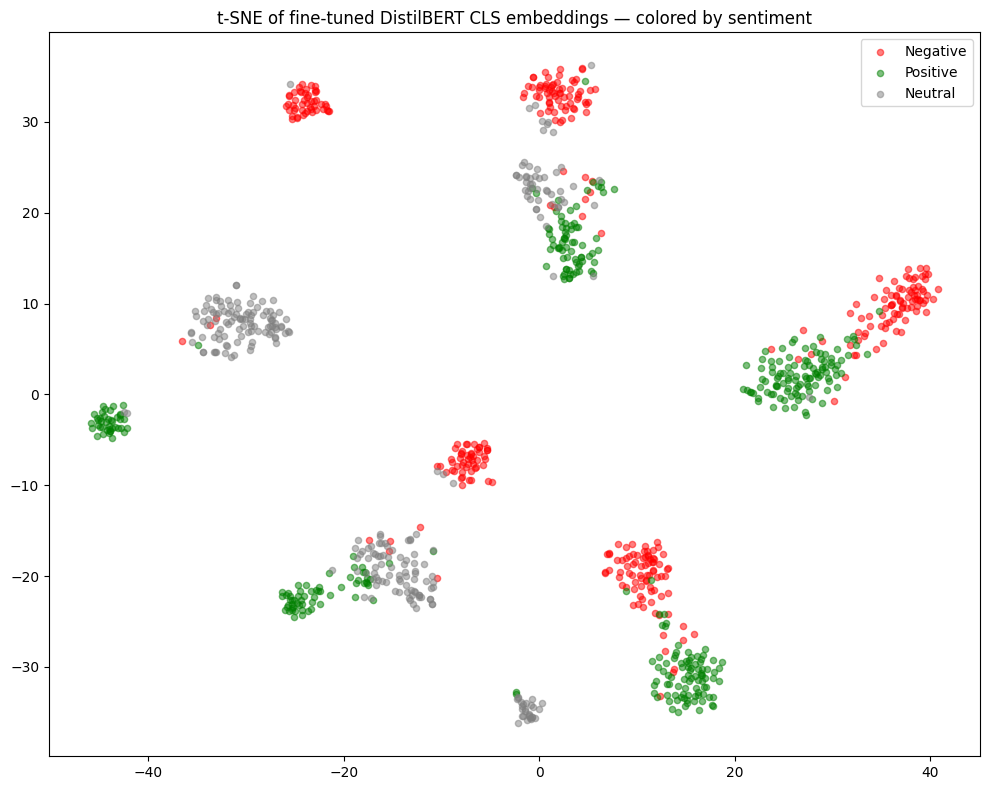

In [21]:
# Fine-tuned model embeddings 
def get_finetuned_cls_embeddings(texts, model, tokenizer, device, batch_size=32):
    all_embeddings = []
    model.eval()
    # Process in batches to avoid OOM on large inputs
    for i in range(0, len(texts), batch_size):
        batch  = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True, max_length=128).to(device)
        with torch.no_grad():
            # Extract backbone embeddings directly (bypassing task heads)
            outputs        = model.backbone(**inputs)
            # Use the [CLS] token as the sentence-level representation
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(cls_embeddings.cpu().numpy())

        # Log progress every 20 batches to avoid flooding stdout
        if (i // batch_size) % 20 == 0:
            print(f"  Processed {min(i + batch_size, len(texts)):,} / {len(texts):,}", end='\r')

    print(f"  Done — {len(texts):,} texts")
    return np.vstack(all_embeddings)


# Rebuild texts and labels from sample_df (overwritten by the predict cell)
sample_size = 200
sample_df   = combined_df.groupby('domain').apply(
    lambda x: x.sample(min(sample_size, len(x)), random_state=42)
).reset_index(drop=True)

texts  = sample_df['text'].tolist()
labels = sample_df['sentiment'].tolist()

print("Extracting fine-tuned DistilBERT embeddings...")
ft_embeddings = get_finetuned_cls_embeddings(texts, model, tokenizer, device)

# Reduce 768-dim CLS embeddings to 2D for visualization
print("Running t-SNE...")
ft_reduced = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(ft_embeddings)

# Color points by sentiment to assess how well the model separates sentiment in embedding space
sentiment_colors = {
    'negative': ('Negative', 'red'),
    'positive': ('Positive', 'green'),
    'neutral':  ('Neutral',  'gray'),
}

plt.figure(figsize=(10, 8))
for sent_val, (sent_name, color) in sentiment_colors.items():
    mask = [l == sent_val for l in labels]
    pts  = ft_reduced[np.array(mask)]
    plt.scatter(pts[:, 0], pts[:, 1], c=color, label=sent_name, alpha=0.5, s=20)

plt.legend()
plt.title('t-SNE of fine-tuned DistilBERT CLS embeddings — colored by sentiment')
plt.tight_layout()
plt.show()